# Phase 2 → Lesson 4: Decision Trees & Random Forest
What is a Decision Tree?

Decison tree ask a question yes/no instead of making linearly seperable line
Linear and Logistic Regression draw lines to make decisions. But real world data isn't always linearly separable.

Real world examples:

Should we approve this loan? (Yes/No)
Is this tumor malignant? (Yes/No)
Which product category does this belong to?

DecisionTreeClassifier() → the decision tree model

max_depth=3 → limits tree to 3 levels of questions — prevents overfitting

X now has 2 features — tree can ask questions about both

Everything else same as Logistic Regression — sklearn is consistent!


| points | Gini (technical algo CART) | Entropy (thoeritical notes algo ID3) |
| :--- | :--- | :--- |
| **main purpoes** | Confusion ko khatam karna | Confusion ko khatam karna |
| **Best Box Value** | gini = 0.0 (Bilkul Saaf) | entropy = 0.0 (Bilkul Saaf) |
| **Kaam ka Usool** | Reduction in Gini | Higher Information Gain cause reduction in entropy|


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report

# Dataset
data = {
    'StudyHours':  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Attendance':  [60, 65, 70, 75, 80, 85, 90, 95, 95, 98],
    'Passed':      [0,  0,  0,  0,  1,  1,  1,  1,  1,  1]}

df=pd.DataFrame(data)
print(f'{df}\n')
print(f'{df.describe()}\n')
#feature intilization
X=df[['StudyHours','Attendance']]
Y=df['Passed']
#train and test data splitting
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
#create and train
model=DecisionTreeClassifier()
model.fit(X_train,Y_train)
#predict
Y_pred=model.predict(X_test)
#checking and matching the data with train along with test
print(f'Y_test: {Y_test}\n')
print(f'Y_pred: {Y_pred}\n')

print(f'Actual:    {list(Y_test)}')
print(f'Predicted: {list(Y_pred)}')
print(f'Accuracy:  {accuracy_score(Y_test,Y_pred):.2f}')

   StudyHours  Attendance  Passed
0           1          60       0
1           2          65       0
2           3          70       0
3           4          75       0
4           5          80       1
5           6          85       1
6           7          90       1
7           8          95       1
8           9          95       1
9          10          98       1

       StudyHours  Attendance     Passed
count    10.00000   10.000000  10.000000
mean      5.50000   81.300000   0.600000
std       3.02765   13.466419   0.516398
min       1.00000   60.000000   0.000000
25%       3.25000   71.250000   0.000000
50%       5.50000   82.500000   1.000000
75%       7.75000   93.750000   1.000000
max      10.00000   98.000000   1.000000

Y_test: 8    1
1    0
Name: Passed, dtype: int64

Y_pred: [1 0]

Actual:    [1, 0]
Predicted: [np.int64(1), np.int64(0)]
Accuracy:  1.00


# Visualizing the Tree
plot_tree() → draws the actual tree structure

feature_names → column names for display

class_names → label names for display it tells what is the kast decisions Fail or Pass.

filled=True → colors nodes by class (blue=Pass, orange=Fail)

rounded=True → rounded corners — easier to read

model.feature_importances_ → how much each feature contributed to decisions

Higher score = more important feature

In ML this tells you which features actually matter for your model

🔑 Feature importance is one of the most useful tools in ML — it helps you remove useless features and keep only what matters. Used in every real project.


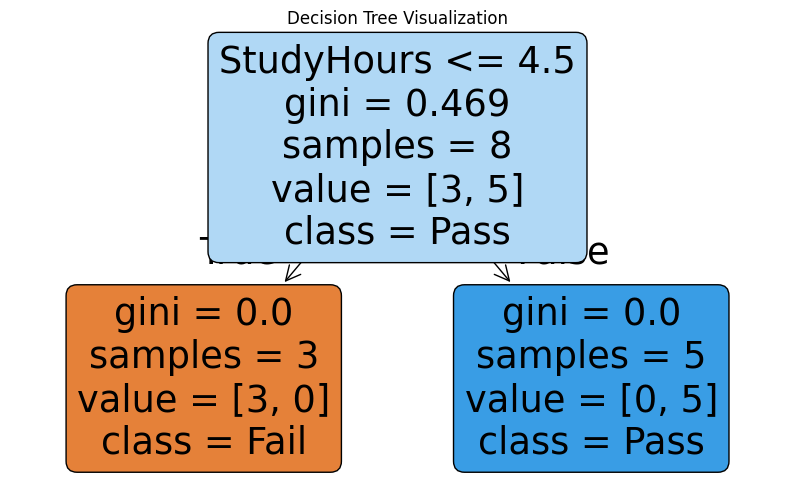

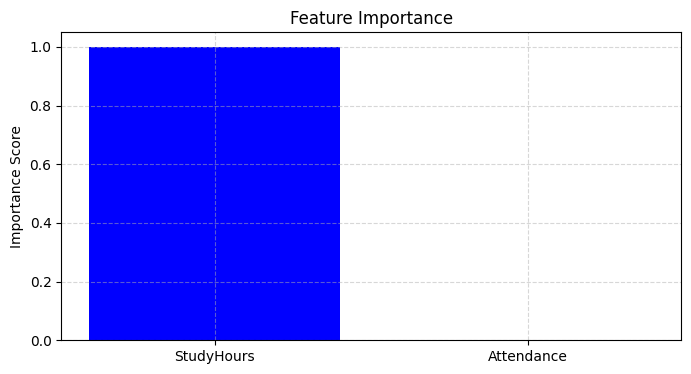

StudyHours: 1.000
Attendance: 0.000
 the result we take from our model is that for pass/fail study hours matter alot rather than attendance


In [2]:
# 1. Tree Visualization
plt.figure(figsize=(10,6))
plot_tree(model, feature_names=X.columns, class_names=['Fail','Pass'], filled=True, rounded=True)
plt.title('Decision Tree Visualization')
plt.show()

# 2. Feature Importance Scores
imp = model.feature_importances_

#  CORRECTION: Double brackets [[]] to SINGLE brackets []
features = ['StudyHours', 'Attendance']

# 3. Bar Chart Plotting
plt.figure(figsize=(8, 4))
plt.bar(features, imp, color=['blue', 'green'])
plt.title('Feature Importance')
plt.ylabel('Importance Score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 4. Printing Scores
for feat, importance_val in zip(features, imp):
    print(f'{feat}: {importance_val:.3f}')

print(' the result we take from our model is that for pass/fail study hours matter alot rather than attendance')

#What is Random Forest?
A single Decision Tree has one big problem — overfitting. It memorizes training data too well.

Random Forest solution: Build hundreds of trees and let them vote! to win....

🔑 Random Forest is one of the most powerful and most used ML algorithms in real world projects. It almost always outperforms a single Decision Tree.

RandomForestClassifier(n_estimators=100) → builds 100 decision trees

n_estimators → number of trees (more = better but slower)

Everything else identical to Decision Tree — same sklearn pattern

Random Forest Accuracy: 1.00

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



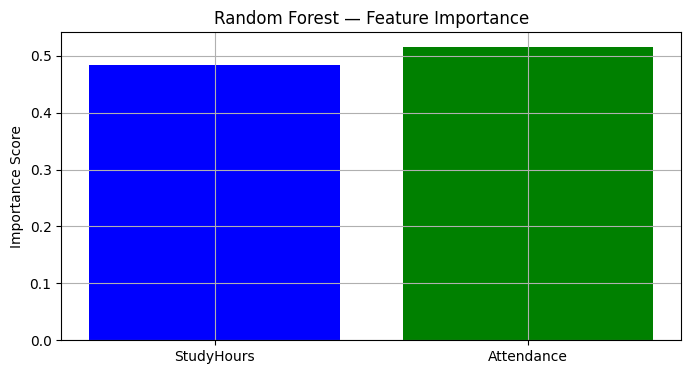

StudyHours: 0.485
Attendance: 0.515


In [3]:
from sklearn.ensemble import RandomForestClassifier

# Same data, same split — just different model!
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)

rf_pred = rf_model.predict(X_test)

print(f'Random Forest Accuracy: {accuracy_score(Y_test, rf_pred):.2f}')
print(f'\n{classification_report(Y_test, rf_pred)}')

# Feature importance from Random Forest
rf_importance = rf_model.feature_importances_
plt.figure(figsize=(8, 4))
plt.bar(features, rf_importance, color=['blue', 'green'])
plt.title('Random Forest — Feature Importance')
plt.ylabel('Importance Score')
plt.grid(True)
plt.show()
for feat, importance_val in zip(features, rf_importance):
    print(f'{feat}: {importance_val:.3f}')
